In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Required libraries has been loaded successfully")

Required libraries has been loaded successfully


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [8]:
df = pd.read_csv('Mall_Customers.csv')

print("Data has been loaded ")
print("Shape (rows, columns):", df.shape)
print("\nFirst 5 customers:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData's summary:")
print(df.describe())

Data has been loaded 
Shape (rows, columns): (200, 5)

First 5 customers:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Column names:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data's summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000 

In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print("Features are ready to be used")
print("Shape:", X.shape)
print("\nFirst  5 rows:")
print(X.head())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData has been normalized ")
print("Pehle 3 rows (scaled):")
print(X_scaled[:3])

Features are ready to be used
Shape: (200, 2)

First  5 rows:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40

Data has been normalized 
Pehle 3 rows (scaled):
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]]


K values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Inertia: [400.0, 269.69, 157.7, 108.92, 65.57, 55.06, 44.86, 37.23, 32.39, 29.98]


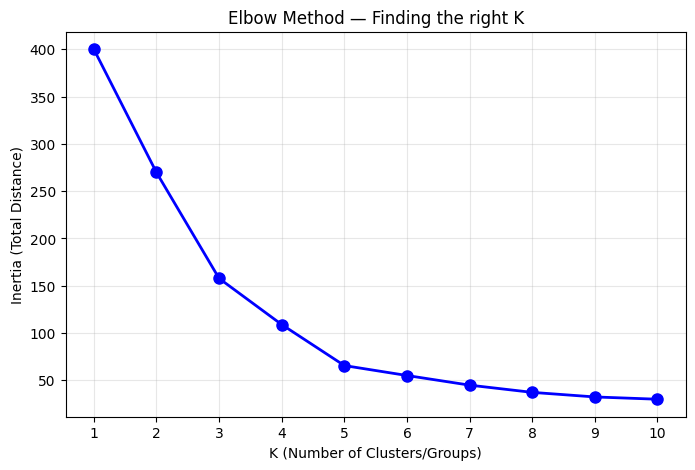

Elbow graph has been generated


In [10]:
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

print("K values:", list(k_range))
print("Inertia:", [round(i, 2) for i in inertia_values])

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K (Number of Clusters/Groups)')
plt.ylabel('Inertia (Total Distance)')
plt.title('Elbow Method — Finding the right K')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('elbow.png')
plt.show()
print("Elbow graph has been generated")

In [11]:
k = 5

kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

df['Cluster'] = kmeans_final.labels_

print("Model has been trained")
print("\nNumber of customers in each group:")
print(df['Cluster'].value_counts().sort_index())
print("\nFirst 10 customers and their  group:")
print(df[['Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head(10))

Model has been trained

Number of customers in each group:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

First 10 customers and their  group:
   Annual Income (k$)  Spending Score (1-100)  Cluster
0                  15                      39        4
1                  15                      81        2
2                  16                       6        4
3                  16                      77        2
4                  17                      40        4
5                  17                      76        2
6                  18                       6        4
7                  18                      94        2
8                  19                       3        4
9                  19                      72        2


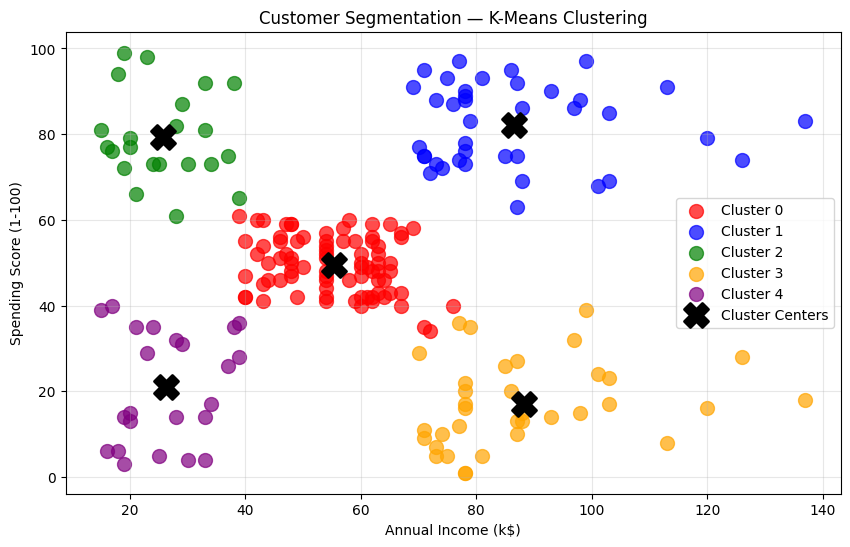

Cluster graph has been generated


In [12]:
colors = ['red', 'blue', 'green', 'orange', 'purple']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

plt.figure(figsize=(10, 6))

for i in range(k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
                cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                c=colors[i],
                label=cluster_names[i],
                alpha=0.7,
                s=100 )

centers = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=300, linewidths=2, label='Cluster Centers', zorder=5)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation — K-Means Clustering')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('clusters.png')
plt.show()
print("Cluster graph has been generated")

In [14]:
analysis = []

for i in range(k):
    cluster_data = df[df['Cluster'] == i]

    avg_income = cluster_data['Annual Income (k$)'].mean()
    avg_spending = cluster_data['Spending Score (1-100)'].mean()
    count = len(cluster_data)

    if avg_income > 70 and avg_spending > 60:
        label = "VIP Customers (High Income + High Spending)"
    elif avg_income > 70 and avg_spending < 40:
        label = "Careful Customers (High Income + Low Spending)"
    elif avg_income < 40 and avg_spending > 60:
        label = "Impulsive Buyers (Low Income + High Spending)"
    elif avg_income < 40 and avg_spending < 40:
        label = "Budget Shoppers (Low Income + Low Spending)"
    else:
        label = "Average Customers (Moderate Income + Moderate Spending)"

    analysis.append({
        "Group": i,
        "Customer Type": label,
        "Customers": count,
        "Avg Income (k$)": round(avg_income, 1),
        "Avg Spending": round(avg_spending, 1)
    })

analysis_df = pd.DataFrame(analysis)

from IPython.display import display
display(analysis_df)

,Group,Customer Type,Customers,Avg Income (k$),Avg Spending
0,0,Average Customers (Moderate Income + Moderate ...,81,55.3,49.5
1,1,VIP Customers (High Income + High Spending),39,86.5,82.1
2,2,Impulsive Buyers (Low Income + High Spending),22,25.7,79.4
3,3,Careful Customers (High Income + Low Spending),35,88.2,17.1
4,4,Budget Shoppers (Low Income + Low Spending),23,26.3,20.9


In [20]:
# Single Customer Prediction
new_customer = pd.DataFrame({
    'Annual Income (k$)': [80],
    'Spending Score (1-100)': [85]
})

new_scaled = scaler.transform(new_customer)
predicted_cluster = kmeans_final.predict(new_scaled)[0]

single_customer = pd.DataFrame({
    "Annual Income (k$)": [80],
    "Spending Score": [85],
    "Predicted Cluster": [predicted_cluster]
})

from IPython.display import display

display(single_customer)


# Multiple Customer Predictions
test_customers = [
    [15, 20],
    [90, 90],
    [50, 50],
    [80, 10],
    [20, 80],
]

predictions = []

for c in test_customers:
    customer = pd.DataFrame([c],columns=['Annual Income (k$)', 'Spending Score (1-100)'])
    scaled = scaler.transform(customer)
    group = kmeans_final.predict(scaled)[0]
    predictions.append({
        "Annual Income (k$)": c[0],
        "Spending Score": c[1],
        "Predicted Cluster": group
    })

predictions_df = pd.DataFrame(predictions)

display(predictions_df)

,Annual Income (k$),Spending Score,Predicted Cluster
0,80,85,1


,Annual Income (k$),Spending Score,Predicted Cluster
0,15,20,4
1,90,90,1
2,50,50,0
3,80,10,3
4,20,80,2
